<a href="https://colab.research.google.com/github/tupii-7/Data-Visualization/blob/main/praktikum4_60324023_SaidFachriAriza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Menyiapkan Notebook dan Mengimpor Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
print("Versi Matplotlib:", matplotlib.__version__)

Versi Matplotlib: 3.10.0


Memuat Dataset Auto MPG

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)
print(df.shape)
df.head()

(398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


Memeriksa dan Menangani Missing Value

In [ ]:

# Pengecekan data kosong sebelum diisi
print(df.isnull().sum())

# Mengisi data kosong pada kolom horsepower dengan nilai median (DISATUKAN DALAM SATU BARIS)
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())

# Pengecekan data kosong setelah diisi
print("Data kosong horsepower setelah diisi:", df["horsepower"].isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64
Data kosong horsepower setelah diisi: 0


Memahami Figure dan Axes

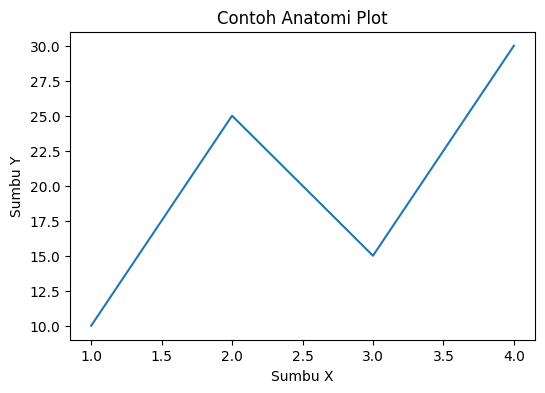

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([1, 2, 3, 4], [10, 25, 15, 30])
ax.set_title("Contoh Anatomi Plot")
ax.set_xlabel("Sumbu X")
ax.set_ylabel("Sumbu Y")
plt.show()

Membuat Line Chart

model_year
70    17.69
71    21.25
72    18.71
73    17.10
74    22.70
Name: mpg, dtype: float64


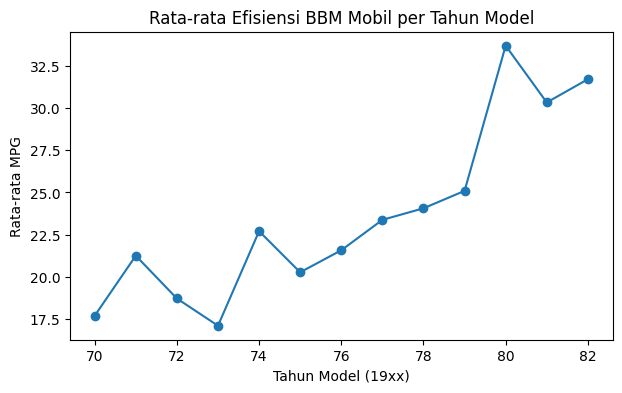

In [ ]:
mpg_per_tahun = df.groupby("model_year")["mpg"].mean()
print(mpg_per_tahun.round(2).head())
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mpg_per_tahun.index, mpg_per_tahun.values, marker="o")
ax.set_title("Rata-rata Efisiensi BBM Mobil per Tahun Model")
ax.set_xlabel("Tahun Model (19xx)")
ax.set_ylabel("Rata-rata MPG")
plt.show()

Membuat Bar Chart

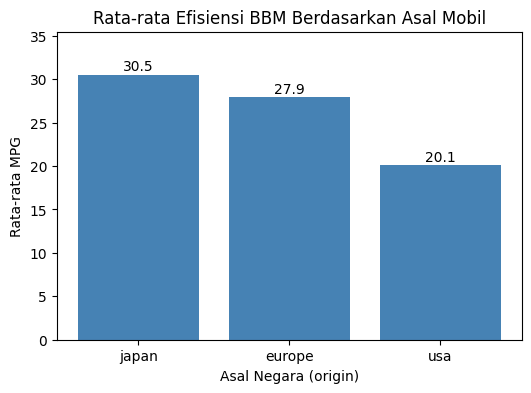

In [ ]:
# 2. Menhitung rata-rata MPG per negara asal (diurutkan dari yang tertinggi)
mpg_per_asal = df.groupby("origin")["mpg"].mean().sort_values(ascending=False)

# 3. Membuat Bar Chart
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(mpg_per_asal.index, mpg_per_asal.values, color="steelblue")
ax.set_title("Rata-rata Efisiensi BBM Berdasarkan Asal Mobil")
ax.set_xlabel("Asal Negara (origin)")
ax.set_ylabel("Rata-rata MPG")

# Opsional: Menampilkan nilai angka di atas setiap batang
for i, v in enumerate(mpg_per_asal.values):
    ax.text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=10)

ax.set_ylim(0, max(mpg_per_asal.values) + 5)
plt.show()

Membuat Scatter Plot

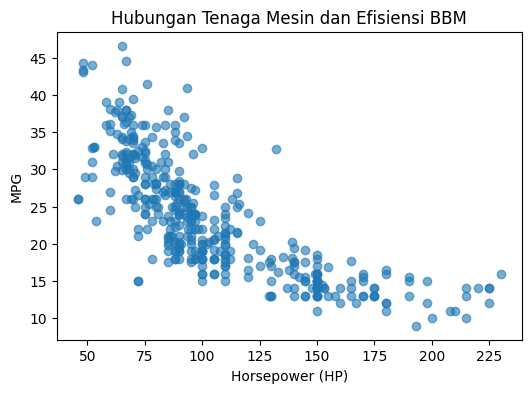

Korelasi: -0.773


In [ ]:
# 2. Membuat Scatter Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["horsepower"], df["mpg"], alpha=0.6, color="tab:blue")
ax.set_title("Hubungan Tenaga Mesin dan Efisiensi BBM")
ax.set_xlabel("Horsepower (HP)")
ax.set_ylabel("MPG")

# Modul Praktikum Visualisasi Data Pertemuan 5 | Hal. 7 (Diubah jadi komentar)

plt.show()

# 3. Menghitung dan mencetak nilai korelasi Pearson
print("Korelasi:", round(df["horsepower"].corr(df["mpg"]), 3))

### Ringkasan Analisis Visualisasi Data

Berdasarkan grafik-grafik yang telah dibuat sebelumnya, berikut adalah kesimpulan analisisnya:

1. **Rata-rata Efisiensi BBM per Tahun (Line Chart)**:
   * Menunjukkan tren positif di mana efisiensi bahan bakar rata-rata (`mpg`) cenderung terus meningkat dari tahun model 1970 hingga mencapai puncaknya pada tahun 1980, sebelum sedikit stabil di tahun 1981-1982.

2. **Rata-rata Efisiensi BBM Berdasarkan Negara Asal (Bar Chart)**:
   * Mobil asal **Japan** memiliki rata-rata efisiensi bahan bakar tertinggi (~30.5 MPG), disusul oleh **Europe** (~27.9 MPG), dan terakhir **USA** (~20.1 MPG).

3. **Hubungan Tenaga Mesin dan Efisiensi BBM (Scatter Plot)**:
   * Terdapat hubungan korelasi negatif yang kuat (**-0.773**) antara `horsepower` dan `mpg`. Semakin tinggi tenaga mesin (HP), maka efisiensi bahan bakar (`mpg`) cenderung semakin rendah (boros).

Menyimpan Grafik sebagai File Gambar

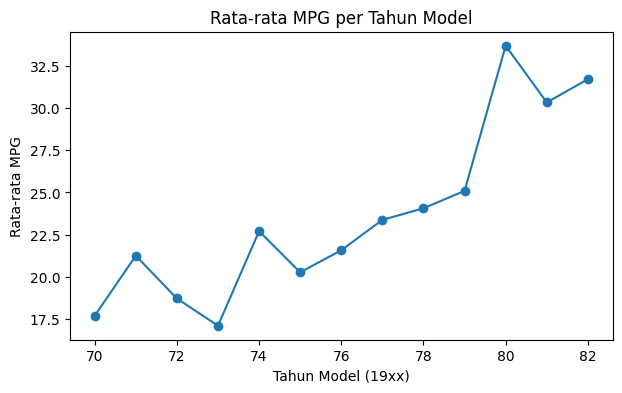

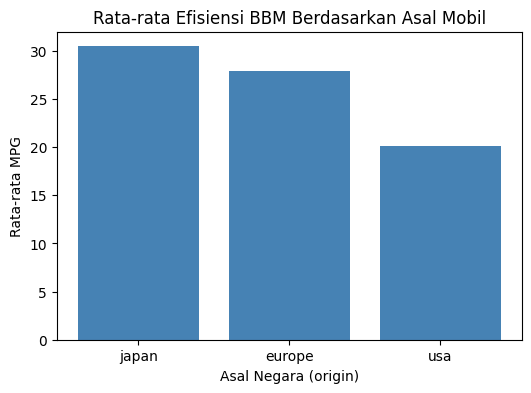

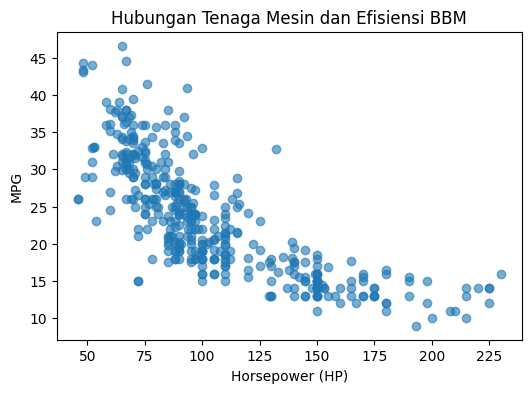

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
mpg_per_tahun = df.groupby("model_year")["mpg"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mpg_per_tahun.index, mpg_per_tahun.values, marker="o", color="tab:blue")
ax.set_title("Rata-rata MPG per Tahun Model")
ax.set_xlabel("Tahun Model (19xx)")
ax.set_ylabel("Rata-rata MPG")

# Menyimpan grafik
fig.savefig("line_mpg_tahun.png", dpi=150, bbox_inches="tight")
plt.show()


# ==========================================
# Langkah 6: Bar Chart (bar_mpg_asal.png)
# ==========================================
mpg_per_asal = df.groupby("origin")["mpg"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(mpg_per_asal.index, mpg_per_asal.values, color="steelblue")
ax.set_title("Rata-rata Efisiensi BBM Berdasarkan Asal Mobil")
ax.set_xlabel("Asal Negara (origin)")
ax.set_ylabel("Rata-rata MPG")

# Menyimpan grafik
fig.savefig("bar_mpg_asal.png", dpi=150, bbox_inches="tight")
plt.show()


# ==========================================
# Langkah 7: Scatter Plot (scatter_hp_mpg.png)
# ==========================================
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df["horsepower"], df["mpg"], alpha=0.6)
ax.set_title("Hubungan Tenaga Mesin dan Efisiensi BBM")
ax.set_xlabel("Horsepower (HP)")
ax.set_ylabel("MPG")

# Menyimpan grafik
fig.savefig("scatter_hp_mpg.png", dpi=150, bbox_inches="tight")
plt.show()

from google.colab import files

# Mengunduh ketiga file yang sudah disimpan sebelumnya
files.download("line_mpg_tahun.png")
files.download("bar_mpg_asal.png")
files.download("scatter_hp_mpg.png")

Mendokumentasikan Proses dan Mengumpulkan Notebook

## Ringkasan Visualisasi Dasar
- **Dataset Auto MPG**: berisi 398 baris dan 9 kolom.
- **Line Chart**: rata-rata MPG per tahun model cenderung menunjukkan tren naik/meningkat dari tahun 1970 hingga mencapai puncaknya di tahun 1980.
- **Bar Chart**: mobil asal **japan** memiliki rata-rata MPG tertinggi (30.5), diikuti oleh europe (27.9) dan usa (20.1).
- **Scatter Plot**: horsepower dan MPG berkorelasi negatif kuat (r = -0.773), artinya semakin besar tenaga mesin (horsepower), maka efisiensi bahan bakar (MPG) akan semakin rendah (boros).
- **Grafik Paling Informatif**: Grafik yang paling informatif menurut saya adalah **Scatter Plot**, karena secara langsung memperlihatkan korelasi negatif yang sangat jelas dan persebaran data hubungan antara performa mesin (horsepower) terhadap efisiensi bahan bakarnya.

# LATIHAN MANDIRI

### Latihan 1: Bar Chart Horizontal Jumlah Mobil per Negara Asal

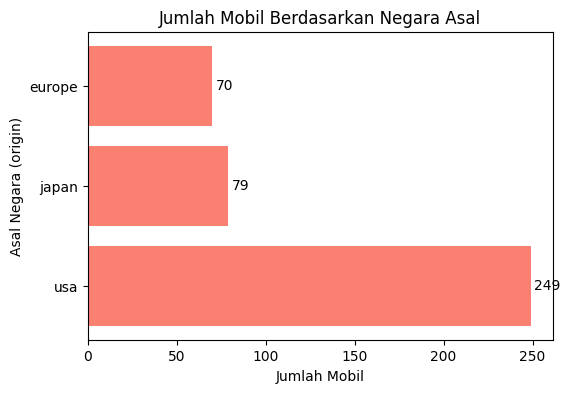

In [ ]:
counts = df['origin'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(counts.index, counts.values, color='salmon')
ax.set_title('Jumlah Mobil Berdasarkan Negara Asal')
ax.set_xlabel('Jumlah Mobil')
ax.set_ylabel('Asal Negara (origin)')

for i, v in enumerate(counts.values):
    ax.text(v + 2, i, str(v), va='center', fontsize=10)

plt.show()

### Latihan 2: Line Chart Rata-rata Weight per Tahun Model

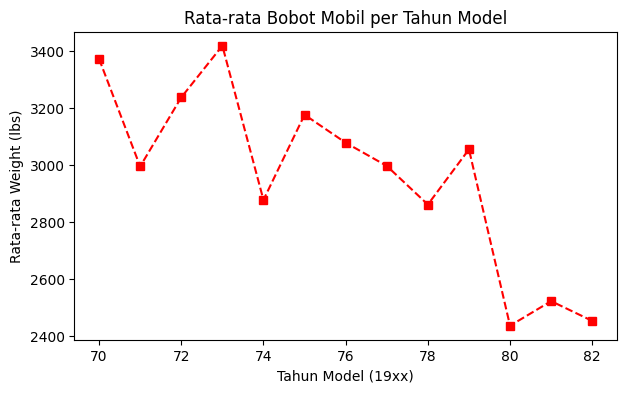

In [ ]:
weight_per_tahun = df.groupby('model_year')['weight'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(weight_per_tahun.index, weight_per_tahun.values, linestyle='--', color='red', marker='s')
ax.set_title('Rata-rata Bobot Mobil per Tahun Model')
ax.set_xlabel('Tahun Model (19xx)')
ax.set_ylabel('Rata-rata Weight (lbs)')
plt.show()

### Latihan 3: Scatter Plot Weight vs MPG dan Korelasinya

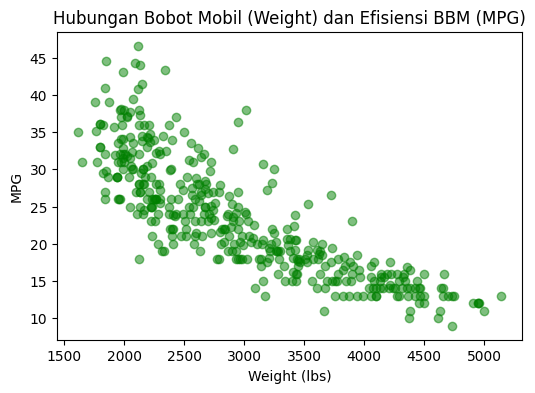

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['weight'], df['mpg'], alpha=0.5, color='green')
ax.set_title('Hubungan Bobot Mobil (Weight) dan Efisiensi BBM (MPG)')
ax.set_xlabel('Weight (lbs)')
ax.set_ylabel('MPG')
plt.show()

korelasi_weight_mpg = df['weight'].corr(df['mpg'])


Korelasi Pearson antara Weight dan MPG: -0.832

Interpretasi: Terdapat hubungan korelasi negatif yang sangat kuat antara bobot mobil dan efisiensi BBM, yang berarti semakin berat suatu mobil, maka konsumsi bahan bakarnya cenderung semakin boros (MPG semakin rendah).

### Latihan 4: Bar Chart Rata-rata MPG Berdasarkan Jumlah Silinder

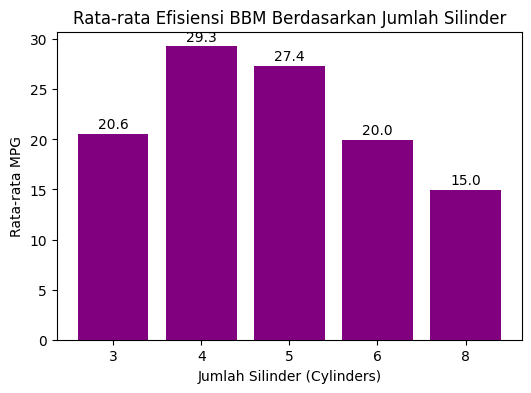

In [ ]:
mpg_per_silinder = df.groupby('cylinders')['mpg'].mean()

fig, ax = plt.subplots(figsize=(6, 4))
# Mengubah index ke tipe string agar setiap batang berdampingan secara kategoris
ax.bar(mpg_per_silinder.index.astype(str), mpg_per_silinder.values, color='purple')
ax.set_title('Rata-rata Efisiensi BBM Berdasarkan Jumlah Silinder')
ax.set_xlabel('Jumlah Silinder (Cylinders)')
ax.set_ylabel('Rata-rata MPG')

for i, v in enumerate(mpg_per_silinder.values):
    ax.text(i, v + 0.5, f"{v:.1f}", ha='center', fontsize=10)

plt.show()


Jumlah silinder dengan rata-rata MPG tertinggi adalah 4 silinder (29.3 MPG).

Jumlah silinder dengan rata-rata MPG terendah adalah 8 silinder (15.0 MPG)

### Latihan 5: Visualisasi Hubungan Displacement dan Acceleration

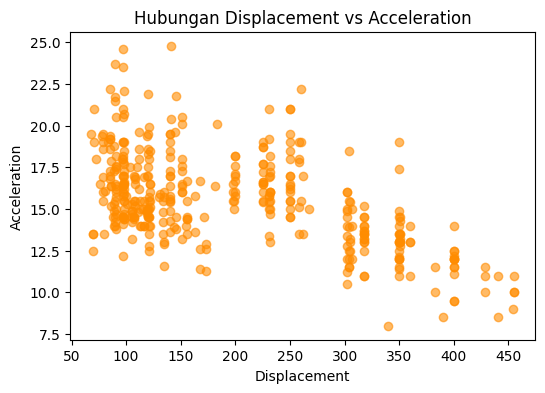

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['displacement'], df['acceleration'], alpha=0.6, color='darkorange')
ax.set_title('Hubungan Displacement vs Acceleration')
ax.set_xlabel('Displacement')
ax.set_ylabel('Acceleration')
plt.show()

Alasan pemilihan grafik: Scatter plot adalah jenis grafik yang paling tepat karena kedua variabel (displacement dan acceleration) bertipe numerik kontinu, sehingga sangat ideal untuk melihat pola persebaran dan arah hubungan kedua variabel tersebut.

Interpretasi: Grafik menunjukkan tren korelasi negatif moderat, yang berarti mobil dengan kapasitas mesin (displacement) lebih besar cenderung membutuhkan waktu akselerasi yang lebih singkat angka akselerasi lebih rendah menunjukkan akselerasi yang lebih cepat